Files in dataset:
['u.occupation', 'u1.base', 'u.info', 'u4.test', 'u.item', 'README', 'u1.test', 'ua.test', 'u.data', 'u5.test', 'mku.sh', 'u5.base', 'u.user', 'ub.base', 'u4.base', 'u2.test', 'ua.base', 'u3.test', 'u.genre', 'allbut.pl', 'u3.base', 'u2.base', 'ub.test']

Training data: (80000, 4)
Testing data : (20000, 4)

Training sample:


,user_id,movie_id,rating,timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712



Movies: (1682, 24)


,movie_id,movie_title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995



Missing values:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Average rating: 3.53


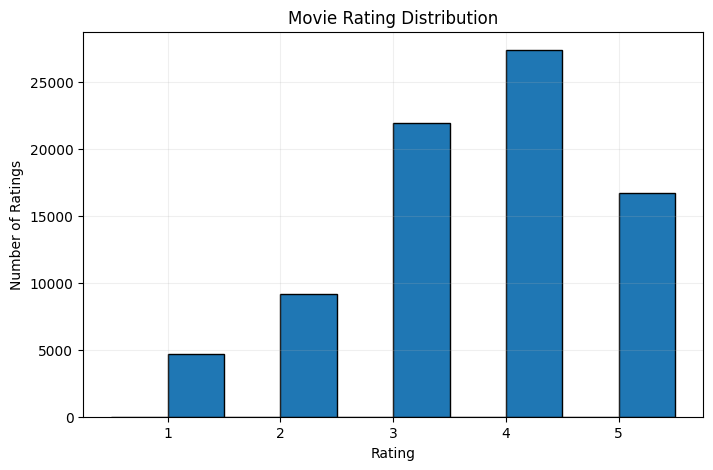


Rating matrix shape: (943, 1650)
Ratings used: 80000

SVD model trained
Explained variance: 0.369

Model evaluation
----------------
Test samples: 19968
MAE : 0.8159
RMSE: 1.0282


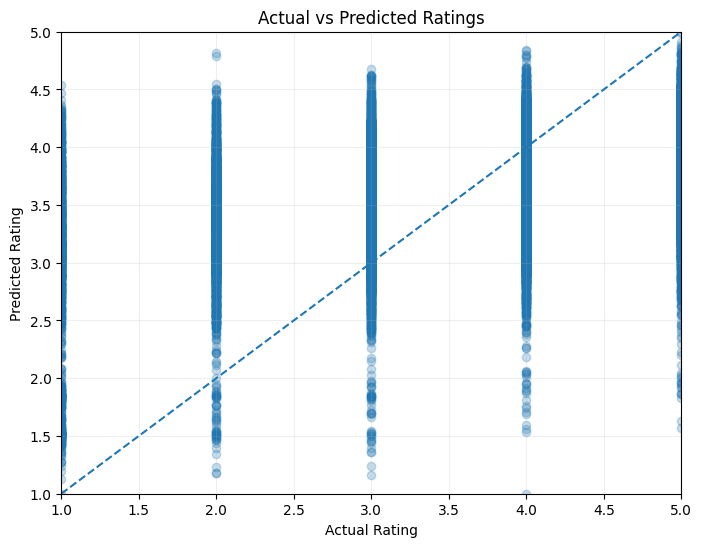

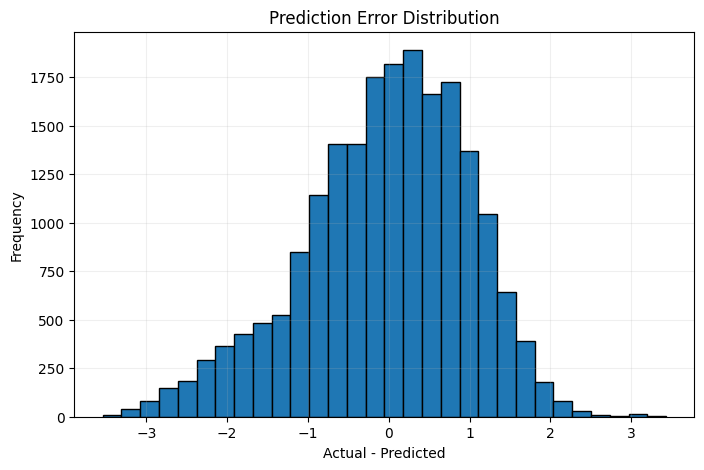


Sample predictions:


,Actual Rating,Predicted Rating,Absolute Error
0,5,3.64,1.36
1,3,3.68,0.68
2,5,3.62,1.38
3,5,3.86,1.14
4,3,3.52,0.52
5,4,3.78,0.22
6,4,3.52,0.48
7,3,3.92,0.92
8,2,3.69,1.69
9,3,3.79,0.79



Selected user: 655

Top 10 recommendations:


,Movie ID,Movie Title,Predicted Rating
0,83,Much Ado About Nothing (1993),3.66
1,259,George of the Jungle (1997),3.62
2,472,Dragonheart (1996),3.53
3,616,Night of the Living Dead (1968),3.49
4,485,My Fair Lady (1964),3.48
5,109,Mystery Science Theater 3000: The Movie (1996),3.41
6,542,Pocahontas (1995),3.38
7,487,Roman Holiday (1953),3.36
8,826,"Phantom, The (1996)",3.35
9,615,"39 Steps, The (1935)",3.33



User rating history:


,movie_id,movie_title,rating
0,1,Toy Story (1995),2
1,2,GoldenEye (1995),3
2,4,Get Shorty (1995),2
3,5,Copycat (1995),2
4,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,4
5,7,Twelve Monkeys (1995),3
6,8,Babe (1995),3
7,9,Dead Man Walking (1995),3
8,11,Seven (Se7en) (1995),2
9,12,"Usual Suspects, The (1995)",3



Most rated movies:


,movie_id,Number_of_Ratings,Average_Rating,movie_title
49,50,484,4.36,Star Wars (1977)
180,181,422,4.01,Return of the Jedi (1983)
257,258,402,3.82,Contact (1997)
99,100,395,4.11,Fargo (1996)
293,294,394,3.16,Liar Liar (1997)
287,288,391,3.45,Scream (1996)
285,286,388,3.64,"English Patient, The (1996)"
0,1,383,3.89,Toy Story (1995)
120,121,353,3.39,Independence Day (ID4) (1996)
299,300,352,3.66,Air Force One (1997)



Files saved:
/kaggle/working/movie_recommendations.csv
/kaggle/working/movie_rating_predictions.csv

TASK 4 COMPLETED
Users: 943
Movies: 1650
Training ratings: 80000
Testing ratings: 20000
MAE: 0.8159
RMSE: 1.0282
SVD components: 50


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_absolute_error, mean_squared_error


# dataset path
path = "/kaggle/input/datasets/trishna8/movielens-100k-dataset/ml-100k"

print("Files in dataset:")
print(os.listdir(path))


# -----------------------------
# Load rating data
# -----------------------------

columns = ["user_id", "movie_id", "rating", "timestamp"]

train = pd.read_csv(
    os.path.join(path, "u1.base"),
    sep="\t",
    names=columns
)

test = pd.read_csv(
    os.path.join(path, "u1.test"),
    sep="\t",
    names=columns
)

print("\nTraining data:", train.shape)
print("Testing data :", test.shape)

print("\nTraining sample:")
display(train.head())


# -----------------------------
# Load movie information
# -----------------------------

movie_columns = [
    "movie_id",
    "movie_title",
    "release_date",
    "video_release_date",
    "imdb_url",
    "unknown",
    "action",
    "adventure",
    "animation",
    "children",
    "comedy",
    "crime",
    "documentary",
    "drama",
    "fantasy",
    "film_noir",
    "horror",
    "musical",
    "mystery",
    "romance",
    "sci_fi",
    "thriller",
    "war",
    "western"
]

movies = pd.read_csv(
    os.path.join(path, "u.item"),
    sep="|",
    names=movie_columns,
    encoding="latin-1"
)

print("\nMovies:", movies.shape)

display(
    movies[["movie_id", "movie_title", "release_date"]].head()
)


# -----------------------------
# Basic preprocessing
# -----------------------------

train = train.drop_duplicates()
test = test.drop_duplicates()

train = train[train["rating"].between(1, 5)]
test = test[test["rating"].between(1, 5)]

print("\nMissing values:")
print(train.isnull().sum())

print("\nAverage rating:", round(train["rating"].mean(), 2))


# -----------------------------
# Rating distribution
# -----------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    train["rating"],
    bins=np.arange(0.5, 5.6, 0.5),
    edgecolor="black"
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.2)

plt.show()


# -----------------------------
# Create user/movie indexes
# -----------------------------

users = sorted(train["user_id"].unique())
movie_ids = sorted(train["movie_id"].unique())

user_index = {
    user: i for i, user in enumerate(users)
}

movie_index = {
    movie: i for i, movie in enumerate(movie_ids)
}

index_user = {
    i: user for user, i in user_index.items()
}

index_movie = {
    i: movie for movie, i in movie_index.items()
}


# average rating given by each user
user_mean = train.groupby("user_id")["rating"].mean()

global_mean = train["rating"].mean()


# -----------------------------
# Build rating matrix
# -----------------------------

rows = []
cols = []
values = []

for _, row in train.iterrows():

    user = user_index[row["user_id"]]
    movie = movie_index[row["movie_id"]]

    rating = row["rating"]
    average = user_mean[row["user_id"]]

    rows.append(user)
    cols.append(movie)
    values.append(rating - average)


rating_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(len(users), len(movie_ids))
)

print("\nRating matrix shape:", rating_matrix.shape)
print("Ratings used:", rating_matrix.nnz)


# -----------------------------
# SVD model
# -----------------------------

svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

user_features = svd.fit_transform(rating_matrix)
movie_features = svd.components_

print("\nSVD model trained")
print(
    "Explained variance:",
    round(svd.explained_variance_ratio_.sum(), 3)
)


# -----------------------------
# Generate predictions
# -----------------------------

predicted = user_features @ movie_features

for i, user in enumerate(users):
    predicted[i] += user_mean[user]

predicted = np.clip(predicted, 1, 5)


# -----------------------------
# Evaluate model
# -----------------------------

actual = []
pred = []

for _, row in test.iterrows():

    if row["user_id"] not in user_index:
        continue

    if row["movie_id"] not in movie_index:
        continue

    user = user_index[row["user_id"]]
    movie = movie_index[row["movie_id"]]

    actual.append(row["rating"])
    pred.append(predicted[user, movie])


actual = np.array(actual)
pred = np.array(pred)

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))

print("\nModel evaluation")
print("----------------")
print("Test samples:", len(actual))
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))


# -----------------------------
# Actual vs predicted
# -----------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    actual,
    pred,
    alpha=0.25
)

plt.plot(
    [1, 5],
    [1, 5],
    linestyle="--"
)

plt.title("Actual vs Predicted Ratings")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.grid(alpha=0.2)

plt.show()


# -----------------------------
# Prediction errors
# -----------------------------

errors = actual - pred

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30,
    edgecolor="black"
)

plt.title("Prediction Error Distribution")
plt.xlabel("Actual - Predicted")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)

plt.show()


# -----------------------------
# Prediction results table
# -----------------------------

results = pd.DataFrame({
    "Actual Rating": actual,
    "Predicted Rating": np.round(pred, 2),
    "Absolute Error": np.round(np.abs(actual - pred), 2)
})

print("\nSample predictions:")
display(results.head(15))


# -----------------------------
# Movie recommendation function
# -----------------------------

def recommend_movies(user_id, n=10):

    if user_id not in user_index:
        print("User not found.")
        return None

    user = user_index[user_id]

    watched = set(
        train[
            train["user_id"] == user_id
        ]["movie_id"]
    )

    recommendations = []

    for movie_position, movie_id in index_movie.items():

        if movie_id in watched:
            continue

        score = predicted[user, movie_position]

        recommendations.append(
            [movie_id, score]
        )

    recommendations = pd.DataFrame(
        recommendations,
        columns=["movie_id", "predicted_rating"]
    )

    recommendations = recommendations.sort_values(
        "predicted_rating",
        ascending=False
    ).head(n)

    recommendations = recommendations.merge(
        movies[["movie_id", "movie_title"]],
        on="movie_id",
        how="left"
    )

    recommendations["predicted_rating"] = (
        recommendations["predicted_rating"].round(2)
    )

    recommendations = recommendations[
        [
            "movie_id",
            "movie_title",
            "predicted_rating"
        ]
    ]

    recommendations.columns = [
        "Movie ID",
        "Movie Title",
        "Predicted Rating"
    ]

    return recommendations.reset_index(drop=True)


# -----------------------------
# Generate recommendations
# -----------------------------

sample_user = (
    train["user_id"]
    .value_counts()
    .index[0]
)

print("\nSelected user:", sample_user)

recommendations = recommend_movies(
    sample_user,
    10
)

print("\nTop 10 recommendations:")
display(recommendations)


# -----------------------------
# User rating history
# -----------------------------

history = train[
    train["user_id"] == sample_user
].merge(
    movies[["movie_id", "movie_title"]],
    on="movie_id",
    how="left"
)

history = history[
    ["movie_id", "movie_title", "rating"]
]

print("\nUser rating history:")
display(history.head(15))


# -----------------------------
# Most rated movies
# -----------------------------

movie_stats = (
    train
    .groupby("movie_id")
    .agg(
        Number_of_Ratings=("rating", "count"),
        Average_Rating=("rating", "mean")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[["movie_id", "movie_title"]],
    on="movie_id",
    how="left"
)

movie_stats["Average_Rating"] = (
    movie_stats["Average_Rating"].round(2)
)

movie_stats = movie_stats.sort_values(
    "Number_of_Ratings",
    ascending=False
)

print("\nMost rated movies:")
display(movie_stats.head(10))


# -----------------------------
# Save results
# -----------------------------

recommendations.to_csv(
    "/kaggle/working/movie_recommendations.csv",
    index=False
)

results.to_csv(
    "/kaggle/working/movie_rating_predictions.csv",
    index=False
)

print("\nFiles saved:")
print("/kaggle/working/movie_recommendations.csv")
print("/kaggle/working/movie_rating_predictions.csv")


# -----------------------------
# Final output
# -----------------------------

print("\n==============================")
print("TASK 4 COMPLETED")
print("==============================")

print("Users:", len(users))
print("Movies:", len(movie_ids))
print("Training ratings:", len(train))
print("Testing ratings:", len(test))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("SVD components:", 50)